In [38]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [39]:
def load_data():
    X = np.load("data/X_m.npy")
    y = np.load("data/y_m.npy")
    return X, y

In [40]:
# load dataset
X, y = load_data()

In [41]:
print ('The first element of X is: ', X[0])

The first element of X is:  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+

In [42]:
print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  9


In [43]:
print ('The first element of y is: ', y[0]) # we get an array 1x1
print ('The last element of y is: ', y[-1]) # we get an array 1x1

The first element of y is:  [0]
The last element of y is:  [9]


In [44]:
print ('The shape of X is: ' , X.shape)
print ('The shape of y is: ' , y.shape)

The shape of X is:  (5000, 400)
The shape of y is:  (5000, 1)


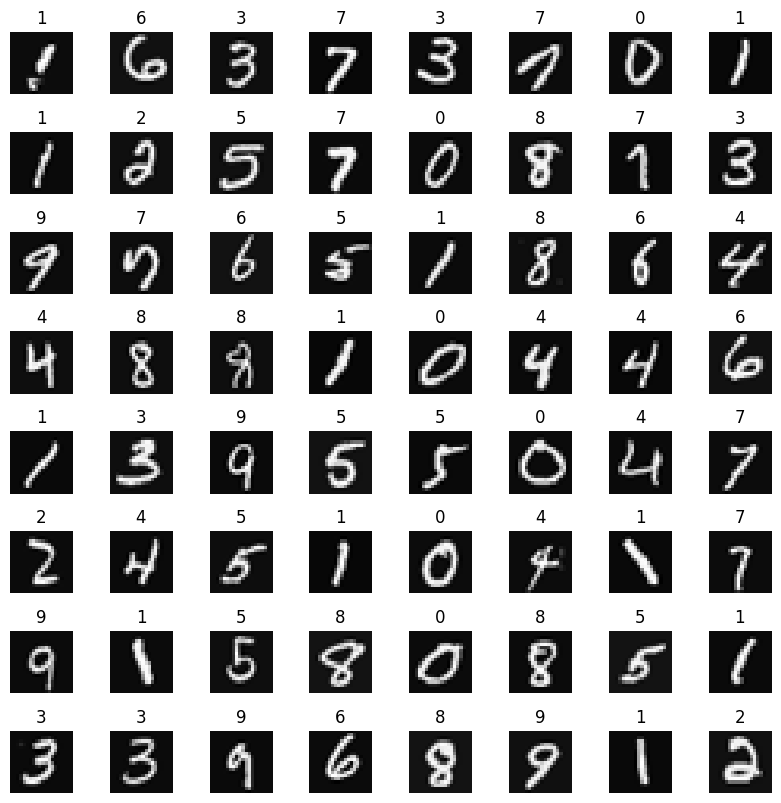

In [45]:
m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1)

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)

    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T

    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    # Display the label above the image
    ax.set_title(y[random_index,0])
    ax.set_axis_off()

# Tensorflow :

# EXO1 :

In [46]:
modelTF = Sequential(
    [
      tf.keras.Input(shape=(400,)),    #specify input size
      ### START CODE HERE ###

      Dense(25, activation='relu', name='layer1'),  # hidden layer 1
      Dense(15, activation='relu', name='layer2'),  # hidden layer 2
      Dense(10, activation='linear', name='layer3'),

      ### END CODE HERE ###
    ], name = "my_model"
)

In [47]:
modelTF.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 10)             │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,575 (41.31 KB)

 Trainable params: 10,575 (41.31 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
[layer1, layer2, layer3] = modelTF.layers
#### Examine Weights shapes
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 10), b3 shape = (10,)


# EXO2 :

In [ ]:
modelTF.compile(
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
)

# tf.keras.optimizers.Adam(learning_rate=0.001) # is better : loss is smaller + faster convergence than in SGD and RMSprop
# tf.keras.optimizers.SGD(learning_rate=0.001)
# tf.keras.optimizers.RMSprop(learning_rate=0.001)


# EXO3 :

In [ ]:
history = modelTF.fit(
    X, y,
    epochs=40
)
# default batch_size is 32 
# 157 = 5000/32 

Epoch 1/40


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0139
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0128
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0153
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0115
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0117
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0122
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0097
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0067
Epoch 9/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0055
Epoch 10/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0054
Epoch 11/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0055
Epoch 12/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0050
Epoch 13/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040
Epoch 14/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0039
Epoch 15/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━

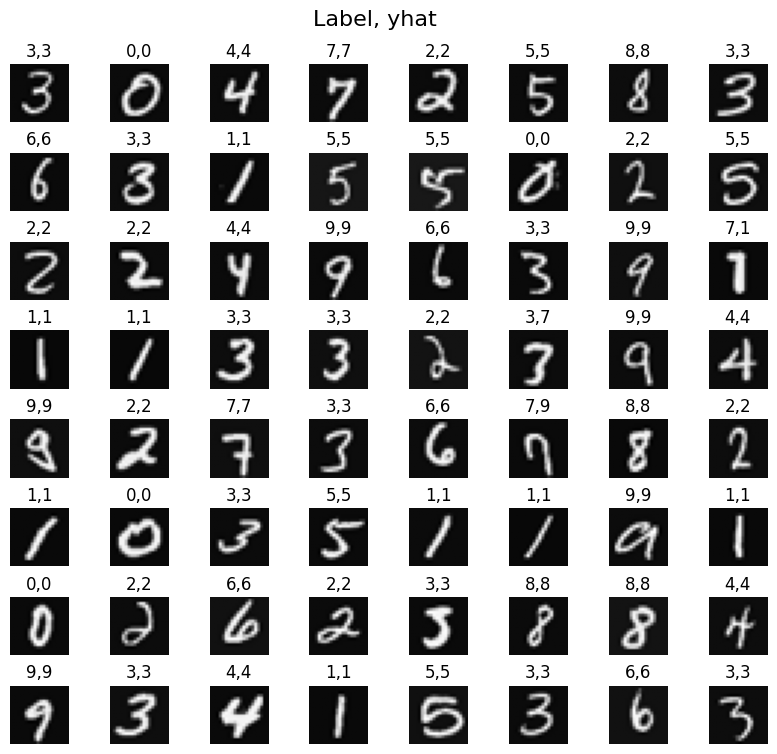

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)

    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T

    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    # Predict using the Neural Network
    prediction = modelTF.predict(X[random_index].reshape(1,400))
    prediction_p = tf.nn.softmax(prediction) #
    yhat = np.argmax(prediction_p)

    # Display the label above the image
    ax.set_title(f"{y[random_index,0]},{yhat}")
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=16)
plt.show()

# pytorch :

# EXO4 :

In [52]:
import torch
import torch.nn as nn

class DigitRecognitionNet(nn.Module):
    def __init__(self):
        super(DigitRecognitionNet, self).__init__()
        # YOUR CODE GOES HERE
        self.layer1 = nn.Linear(400, 25) # input, output
        self.layer2 = nn.Linear(25, 15)
        self.layer3 = nn.Linear(15, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        # YOUR CODE GOES HERE
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

In [53]:
from torchsummary import summary
model = DigitRecognitionNet ()
summary(model, input_size=(1, 400))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 25]          10,025
              ReLU-2                [-1, 1, 25]               0
            Linear-3                [-1, 1, 15]             390
              ReLU-4                [-1, 1, 15]               0
            Linear-5                [-1, 1, 10]             160
Total params: 10,575
Trainable params: 10,575
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04
----------------------------------------------------------------


# EXO5 :

In [80]:
import torch.optim as optim

# YOUR CODE GOES HERE

# Convert data to torch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y[:, 0], dtype=torch.long)   # shape: (5000,)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Adam # better as well
# SGD
# RMSprop

for epoch in range(40):
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)

    optimizer.zero_grad()
    loss.backward()  # gradients
    optimizer.step()  # gradient descent (updating weights)

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.1694
Epoch 2, Loss: 0.1680
Epoch 3, Loss: 0.1676
Epoch 4, Loss: 0.1668
Epoch 5, Loss: 0.1657
Epoch 6, Loss: 0.1647
Epoch 7, Loss: 0.1640
Epoch 8, Loss: 0.1633
Epoch 9, Loss: 0.1626
Epoch 10, Loss: 0.1617
Epoch 11, Loss: 0.1607
Epoch 12, Loss: 0.1599
Epoch 13, Loss: 0.1591
Epoch 14, Loss: 0.1583
Epoch 15, Loss: 0.1575
Epoch 16, Loss: 0.1567
Epoch 17, Loss: 0.1558
Epoch 18, Loss: 0.1549
Epoch 19, Loss: 0.1541
Epoch 20, Loss: 0.1533
Epoch 21, Loss: 0.1525
Epoch 22, Loss: 0.1517
Epoch 23, Loss: 0.1508
Epoch 24, Loss: 0.1500
Epoch 25, Loss: 0.1492
Epoch 26, Loss: 0.1484
Epoch 27, Loss: 0.1476
Epoch 28, Loss: 0.1467
Epoch 29, Loss: 0.1459
Epoch 30, Loss: 0.1451
Epoch 31, Loss: 0.1443
Epoch 32, Loss: 0.1435
Epoch 33, Loss: 0.1427
Epoch 34, Loss: 0.1418
Epoch 35, Loss: 0.1410
Epoch 36, Loss: 0.1402
Epoch 37, Loss: 0.1394
Epoch 38, Loss: 0.1386
Epoch 39, Loss: 0.1378
Epoch 40, Loss: 0.1370


In [55]:
# yes, there's diff between loss in TF and PyTorch
# in pytorch, loss is bigger than in TF, because in pytorch
# reasons :
  # idk, even we used same learning rate, same number of epochs, same loss function, same optimizer

# EXO6 :

Epoch 1, Loss: 2.3170
Epoch 2, Loss: 2.3110
Epoch 3, Loss: 2.3056
Epoch 4, Loss: 2.3001
Epoch 5, Loss: 2.2944
Epoch 6, Loss: 2.2885
Epoch 7, Loss: 2.2822
Epoch 8, Loss: 2.2754
Epoch 9, Loss: 2.2682
Epoch 10, Loss: 2.2605
Epoch 11, Loss: 2.2523
Epoch 12, Loss: 2.2435
Epoch 13, Loss: 2.2342
Epoch 14, Loss: 2.2243
Epoch 15, Loss: 2.2140
Epoch 16, Loss: 2.2033
Epoch 17, Loss: 2.1922
Epoch 18, Loss: 2.1808
Epoch 19, Loss: 2.1690
Epoch 20, Loss: 2.1568
Epoch 21, Loss: 2.1442
Epoch 22, Loss: 2.1312
Epoch 23, Loss: 2.1177
Epoch 24, Loss: 2.1038
Epoch 25, Loss: 2.0894
Epoch 26, Loss: 2.0747
Epoch 27, Loss: 2.0596
Epoch 28, Loss: 2.0440
Epoch 29, Loss: 2.0281
Epoch 30, Loss: 2.0118
Epoch 31, Loss: 1.9951
Epoch 32, Loss: 1.9780
Epoch 33, Loss: 1.9606
Epoch 34, Loss: 1.9427
Epoch 35, Loss: 1.9245
Epoch 36, Loss: 1.9060
Epoch 37, Loss: 1.8871
Epoch 38, Loss: 1.8679
Epoch 39, Loss: 1.8483
Epoch 40, Loss: 1.8282


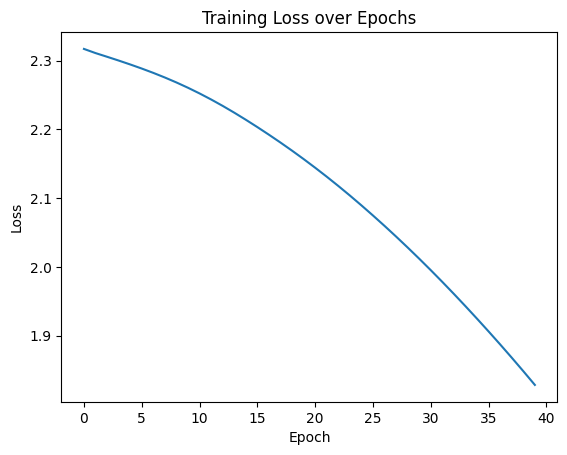

In [ ]:
# YOUR CODE GOES HERE

losses = []

model = DigitRecognitionNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(40):
    model.train()

    outputs = model(X_tensor)          # logits
    loss = criterion(outputs, y_tensor) 

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item()) #

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}") # 

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.show()

In [57]:
import torch.nn.functional as F  # For softmax

with torch.no_grad():  # Disable gradient tracking
    logits = model(X_tensor)  # Get raw logits from the model
    probabilities = F.softmax(logits, dim=1)  # Apply softmax to get probabilities
    Yhat = np.argmax(probabilities.numpy(), axis=1)  # Get predicted class indices

# Convert the prediction to a NumPy array
prediction_np = probabilities.detach().numpy()

# Number of correctly classified samples
correct = np.sum(Yhat == y[:,0])
print('Number of correctly classified samples:', correct)

Number of correctly classified samples: 2410


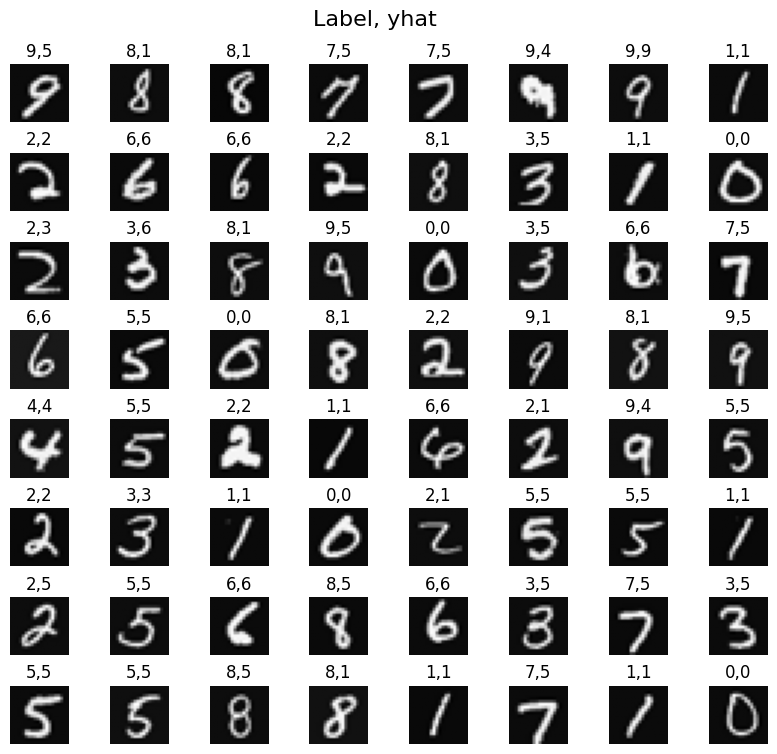

In [58]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)

    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T

    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    # Predict using the Neural Network
    yhat = np.argmax(prediction_np[random_index])

    # Display the label above the image
    ax.set_title(f"{y[random_index,0]},{yhat}")
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=16)
plt.show()


# Numpy :

# EXO7 :

In [59]:
def my_dense(A_in, W, b, g):
  ### START CODE HERE ###

  dense = np.dot(A_in, W) + b
  A_out = g(dense)

  return A_out

  ### END CODE HERE ###

In [60]:
def softmax(z):
  exp_z = np.exp(z - np.max(z))
  return exp_z / np.sum(exp_z)

In [61]:
def relu(z):
  g = np.maximum(0, z)
  return g

In [62]:
def linear(z):
  return z

# EXO8 :

In [63]:
def my_sequential(X, W1, b1, W2, b2, W3, b3):
  # YOUR CODE GOES HERE

  A1 = my_dense(X, W1, b1, relu)
  A2 = my_dense(A1, W2, b2, relu)
  A3 = my_dense(A2, W3, b3, linear)
  
  return A3

In [64]:
W1_tmp,b1_tmp = layer1.get_weights()
W2_tmp,b2_tmp = layer2.get_weights()
W3_tmp,b3_tmp = layer3.get_weights()

In [ ]:
Logit = my_sequential(X, W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
trueLogits = modelTF.predict(X)
if np.sum(Logit - trueLogits > 1e-4)== 0 :
  print("Test passed")
else :
  print("Test not passed")


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Test passed


In [66]:
Prediction = softmax(Logit)

Yhat = np.argmax(Prediction, axis=1)
print("predict a zero: ",Yhat[0], "predict a two: ", Yhat[1015])

predict a zero:  0 predict a two:  2


In [67]:
# Number of correctly classified samples
print('Number of correctly classified sameple of 5000 is:', np.sum(Yhat==y[:,0]))

Number of correctly classified sameple of 5000 is: 4948


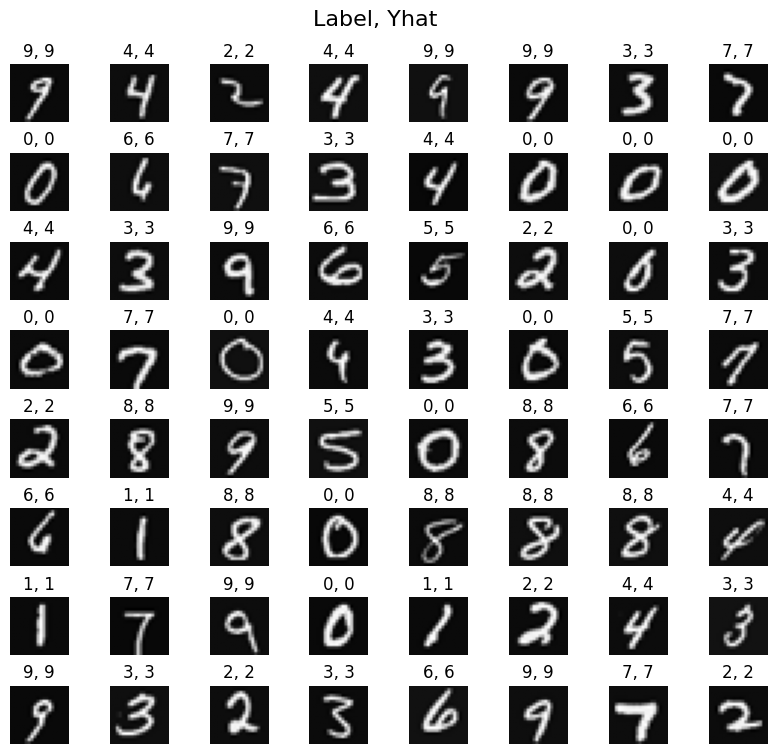

In [68]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i, ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)

    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20, 20)).T

    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    # Display the label above the image
    ax.set_title(f"{y[random_index,0]}, {Yhat[random_index]}")
    ax.set_axis_off()
fig.suptitle("Label, Yhat", fontsize=16)
plt.show()